### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

The dataset gets loaded into a dataframe, and the relevant column indices are extracted. The dataframe is then converted to a GeoDataFrame to better store the coordinates of the data points. The world map data is loaded into another GeoDataFrame, which is then cropped to only include the Americas, and plotted. Then every tribe is plotted on the map by going through every unique population name and creating a scatter plot on the map using the coordinates of the datapoint.

(494, 5717)


/tmp/ipykernel_4695/1350480817.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


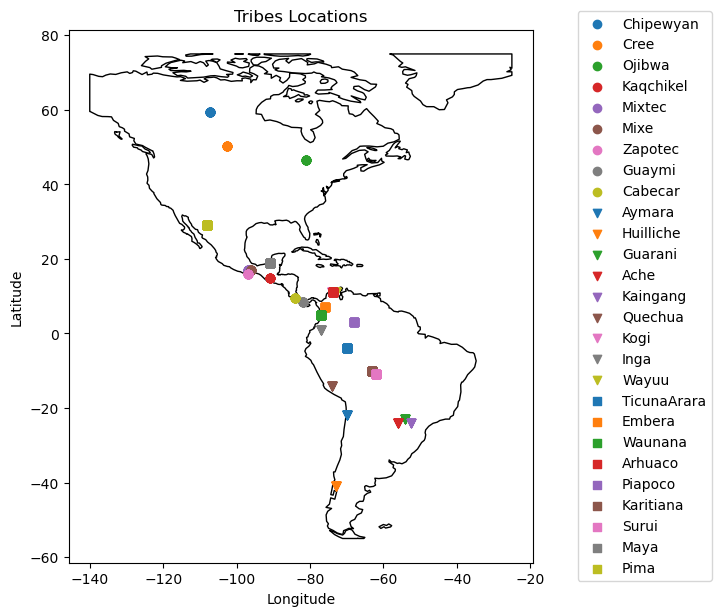

In [2]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')
print(df.shape)

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [3]:
import numpy as np
# Get the genetic markers
X = df[df.columns[8:]].values
print(X.shape)
y = df['long']
print(y.shape)

# Get the regression coefficients
# beta_hat = np.linalg.solve(X.T @ X, X.T @ y)
# print("parameters:")
# print(beta_hat)

(494, 5709)
(494,)


I get the error `Singular matrix`, which means that $X^T X$ is not invertible. Since $rank(X) < p$, and $X^T X$ has size $p \times p$, some of the rows of $X^T X$ will be linearly dependent, which makes it singular.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [4]:
# Estimate the coefficients using least squares
beta_hat, residuals, rank, s = np.linalg.lstsq(X, y)
print("parameters:")
print(beta_hat)

parameters:
[-0.04005781 -0.01940898  0.01111306 ... -0.21729626 -0.10210421
  0.01813644]


Now I get no errors.

This is becaue `numpy.linalg.solve` will always try to solve the provided equation, but `numpy.linalg.lstsq` will solve the system using least squares when the system is overdetermined, but when the system is underdetermined it instead finds the minimum norm solution.

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [5]:
from sklearn.linear_model import LinearRegression

# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
print(lr.coef_)

[-0.03940988 -0.0245272   0.01089763 ...  0.04804479 -0.08985062
  0.01903025]


The coefficients are not the same as before. A reason to perform the re-centering systematically is so that the intercept will be the predicted value when all predictors have their average value, which lets us interpret the intercept as the mean value regardless of the other coefficients.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

Principal component analysis means finding the n components that explain the most variance of the dataset, projecting the data to a lower dimensionality space by taking using the eigenvectors with the highest absolute eigenvalues.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

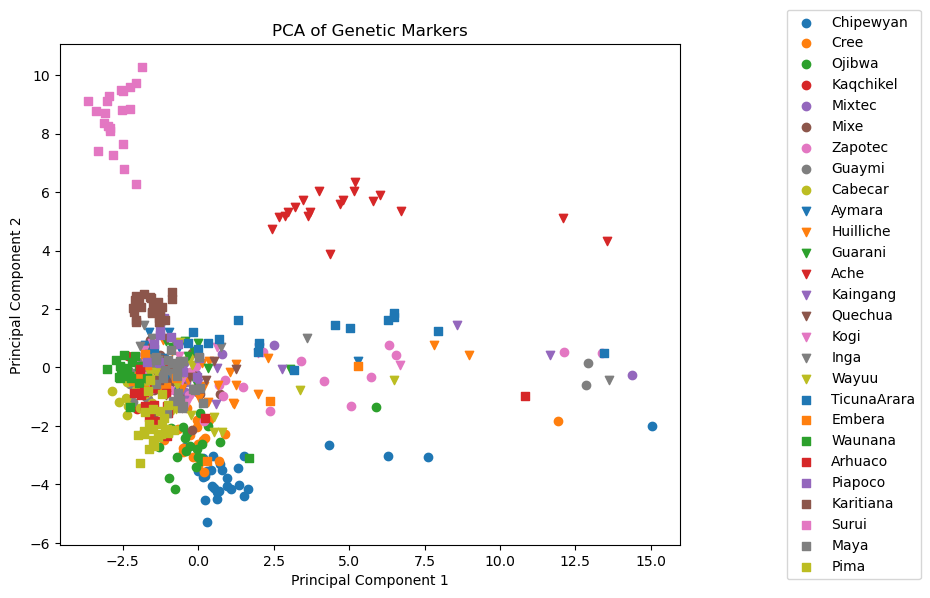

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)
X_reduced = pca.transform(X)

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

fig, ax = plt.subplots(figsize=(8.0, 6.5))

for i, tribe in enumerate(gdf['Pop'].unique()):
    points_tribe = X_reduced[gdf['Pop'] == tribe]
    ax.scatter(points_tribe[:, 0], points_tribe[:, 1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))

ax.set_title('PCA of Genetic Markers')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

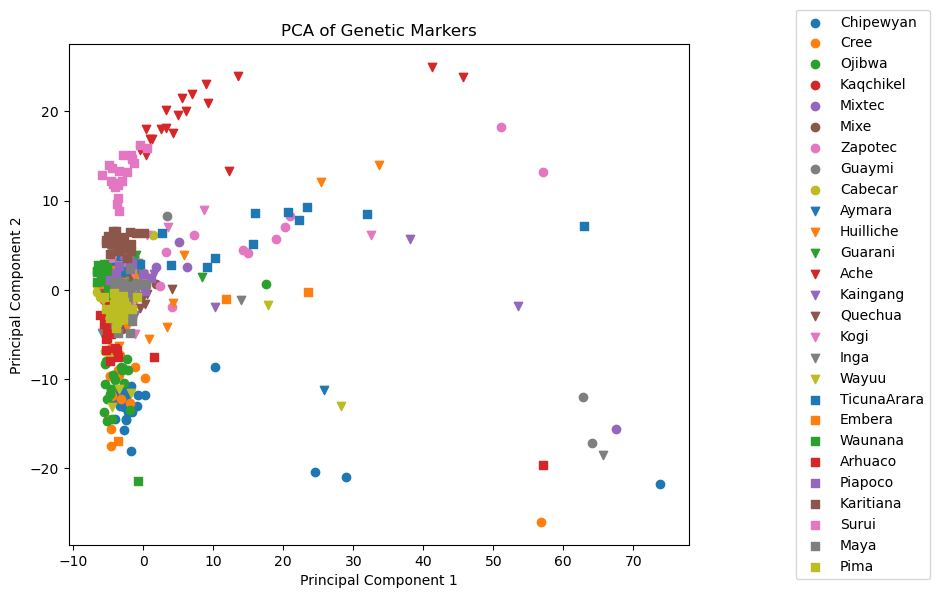

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
pca = PCA(n_components=2)
pca.fit(X_std)
X_reduced_std = pca.transform(X_std)

fig, ax = plt.subplots(figsize=(8.0, 6.5))

for i, tribe in enumerate(gdf['Pop'].unique()):
    points_tribe = X_reduced_std[gdf['Pop'] == tribe]
    ax.scatter(points_tribe[:, 0], points_tribe[:, 1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))

ax.set_title('PCA of Genetic Markers')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
plt.show()

The points are very grouped around 0 on the principal component 1 axis. The variance within each tribe seems to be lower. 

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

The standardizing gives a better separation of the data along principal component 2, but a worse separation along principal component 1. All in all, standardizing the datapoints doesn't seem to improve the performance of the PCA, so it is not necessary.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

Percentage of variance captured by the first two principal components: 3.3929133203688058


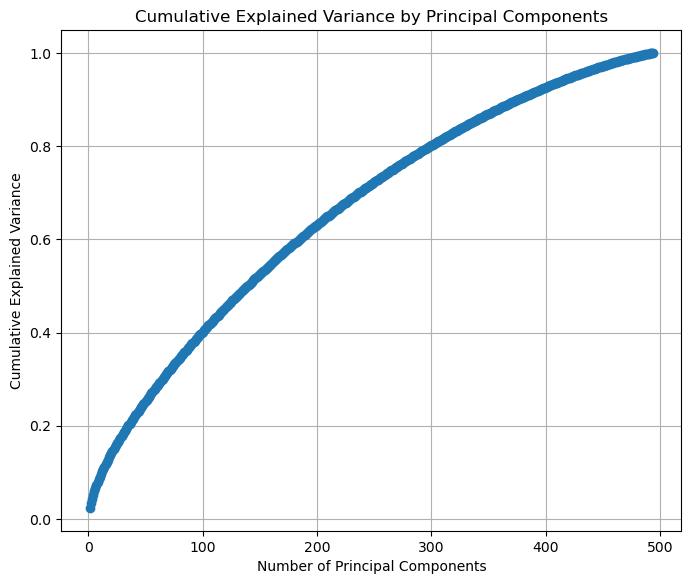

In [8]:
pca = PCA()
pca.fit(X_std)

print("Percentage of variance captured by the first two principal components:", pca.explained_variance_ratio_[:2].sum() * 100)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8.0, 6.5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Principal Components')
plt.grid()
plt.show()

The first two components capture 3.393% of the variance. The graph intersects 50% of the variance at around 150 components. This can be considered as a minimum number of components to keep to explain the majority of the variance of the data. 

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

/tmp/ipykernel_4695/2399366158.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


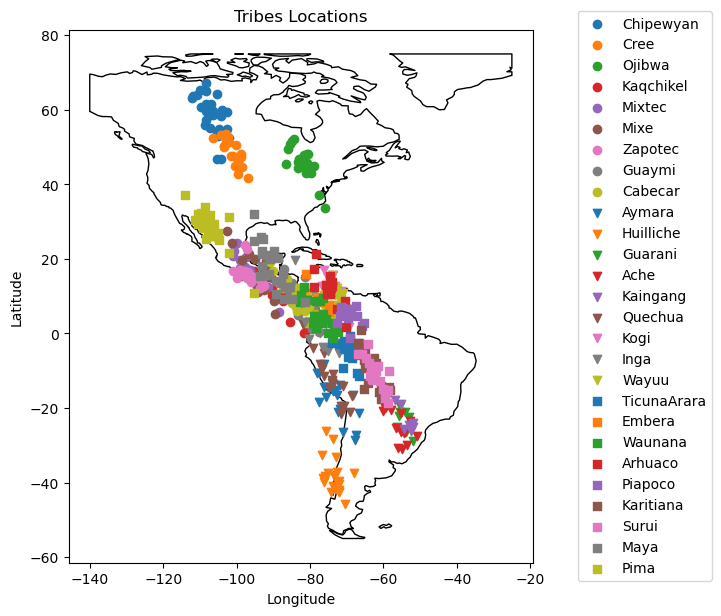

In [9]:
from sklearn.pipeline import make_pipeline

y = df[['long', 'lat']].values

scaler = StandardScaler()
pca = PCA(n_components=250)
regression = LinearRegression()

pipeline = make_pipeline(scaler, pca, regression)
pipeline.fit(X, y)
predictions = pipeline.predict(X)

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = predictions[gdf['Pop'] == tribe]
    ax.scatter(members_tribe[:, 0], members_tribe[:, 1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

The map shows the performance on the training set, so it doesn't say anything about the ability make predictions on points outside the dataset. Using the map to judge the ability to predict points outside the dataset would be way too optimistic. 

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [10]:
from sklearn.metrics.pairwise import haversine_distances

distances = haversine_distances(np.radians(y), np.radians(predictions)) * 6371
mean_error = distances.diagonal().mean()
mean_error_km = mean_error
print(f"Mean error: {mean_error_km:.3f} km")

Mean error: 302.734 km


The mean error is 299.104 km.

## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

Cross validation means saving a part of the dataset to use for testing, in order to estimate the error on data that was not used in training. This gives a better measure of how our model performs, letting us better choose the hyperparameters to get the best bias-variance tradeoff. For data that is not IID, for example due to having a structure with different groups or coming from a time-sensitive process, group-wise cross validation or time-series aware cross validation can be performed. 

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

The data is sorted by country and tribe, meaning that simple k-fold without shuffling will lead to different distributions of the countries and tribes in the training and test set. Using shuffled k-fold reduces the effect of this by making sure the data is not sorted. Another problem could be that the model might overfit to the markers specific to these tribes or countries, making it perform worse at predicting the location of individuals from different tribes or countries. To avoid this, grouped k-fold can be used, which makes sure that each group is in one testing set and no group is in both the training and testing set.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [11]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GroupKFold
kf = KFold(n_splits=10, shuffle=True)
gkf = GroupKFold(n_splits=10, shuffle=True)
groups = groups = gdf['Pop'].values

scaler = StandardScaler()
pca = PCA(n_components=4)
regression = LinearRegression()
pipeline = make_pipeline(scaler, pca, regression)

errors = []

for i, (train, test) in enumerate(kf.split(X, y)):
    X_train, X_test, y_train, y_test = X[train], X[test], y[train], y[test]
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    error = haversine_distances(np.radians(y_test), np.radians(predictions)).diagonal().mean()*6371
    errors.append(error)
    print(f"Error for split {i}: {error:.5f} km")

print(f"Mean error for all splits: {sum(errors)/len(errors):.5f} km\n")

errors = []


for i, (train, test) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_test, y_train, y_test = X[train], X[test], y[train], y[test]
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    error = haversine_distances(np.radians(y_test), np.radians(predictions)).diagonal().mean()*6371
    errors.append(error)
    print(f"Error for split {i}: {error:.5f} km")

print(f"Mean error for all splits: {sum(errors)/len(errors):.5f} km")




Error for split 0: 1337.48070 km
Error for split 1: 1157.80023 km
Error for split 2: 1134.01104 km
Error for split 3: 1284.84377 km
Error for split 4: 1229.08416 km
Error for split 5: 1314.05584 km
Error for split 6: 1233.22699 km
Error for split 7: 1306.54251 km
Error for split 8: 1225.61054 km
Error for split 9: 1316.60567 km
Mean error for all splits: 1253.92615 km

Error for split 0: 2107.56225 km
Error for split 1: 907.66234 km
Error for split 2: 1660.27238 km
Error for split 3: 1259.51701 km
Error for split 4: 1499.79686 km
Error for split 5: 1309.67841 km
Error for split 6: 1949.53976 km
Error for split 7: 1499.46629 km
Error for split 8: 1409.26904 km
Error for split 9: 991.88795 km
Mean error for all splits: 1459.46523 km


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

Mean testing and training error for 2 components: 1534.8831998019866, 1262.0613703926845
Mean testing and training error for 12 components: 1461.8574025509647, 810.1594979370681
Mean testing and training error for 22 components: 1418.0485584844441, 685.38461329647
Mean testing and training error for 32 components: 1394.1699129744916, 611.1972901179764
Mean testing and training error for 42 components: 1382.6710603504146, 563.1984154279639
Mean testing and training error for 52 components: 1376.99610481408, 562.2852022695721
Mean testing and training error for 62 components: 1368.6313850297936, 535.2910454898077
Mean testing and training error for 72 components: 1375.2795133359725, 513.1871520082344
Mean testing and training error for 82 components: 1361.6171241869724, 489.19139964592324
Mean testing and training error for 92 components: 1353.6864979733873, 475.34428297753277
Mean testing and training error for 102 components: 1352.7687156484087, 453.57055440607746
Mean testing and trai

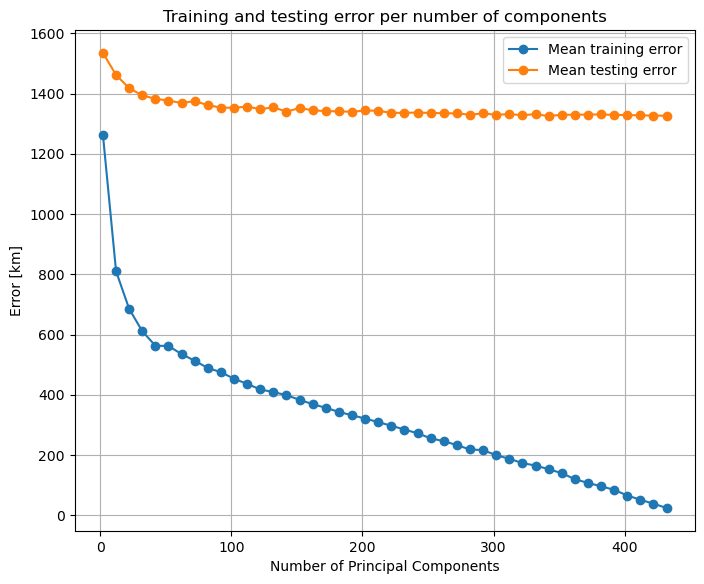

In [12]:
n_components_values = range(2, 441, 10)
mean_training_errors = []
mean_testing_errors = []


gkf = GroupKFold(n_splits=10)


for n in n_components_values:
    scaler = StandardScaler()
    pca = PCA(n_components=n)
    regression = LinearRegression()
    pipeline = make_pipeline(scaler, pca, regression)
    
    training_errors = []
    testing_errors = []

    for train, test in gkf.split(X, y, groups=groups):
        X_train, X_test, y_train, y_test = X[train], X[test], y[train], y[test]
        pipeline.fit(X_train, y_train)
        test_predictions = pipeline.predict(X_test)
        training_predictions = pipeline.predict(X_train)
        training_error = haversine_distances(np.radians(y_train), np.radians(training_predictions)).diagonal().mean()*6371
        testing_error = haversine_distances(np.radians(y_test), np.radians(test_predictions)).diagonal().mean()*6371
        training_errors.append(training_error)
        testing_errors.append(testing_error)



    mean_testing_error = np.mean(testing_errors)
    mean_training_error = np.mean(training_errors)
    print(f"Mean testing and training error for {n} components: {mean_testing_error}, {mean_training_error}")

    mean_testing_errors.append(mean_testing_error)
    mean_training_errors.append(mean_training_error)


plt.figure(figsize=(8.0, 6.5))
plt.plot(n_components_values, mean_training_errors, marker='o', label="Mean training error")
plt.plot(n_components_values, mean_testing_errors, marker='o', label="Mean testing error")
plt.xlabel('Number of Principal Components')
plt.ylabel('Error [km]')
plt.title('Training and testing error per number of components')
plt.grid()
plt.legend()
plt.show()

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

I would keep 192 components, as it explains more than 50% of the variance and gives a testing error that is close to the minimum found. It gives a prediction error of 1339.68 km and a training error of 332.33 km. 

/tmp/ipykernel_4695/1276178758.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


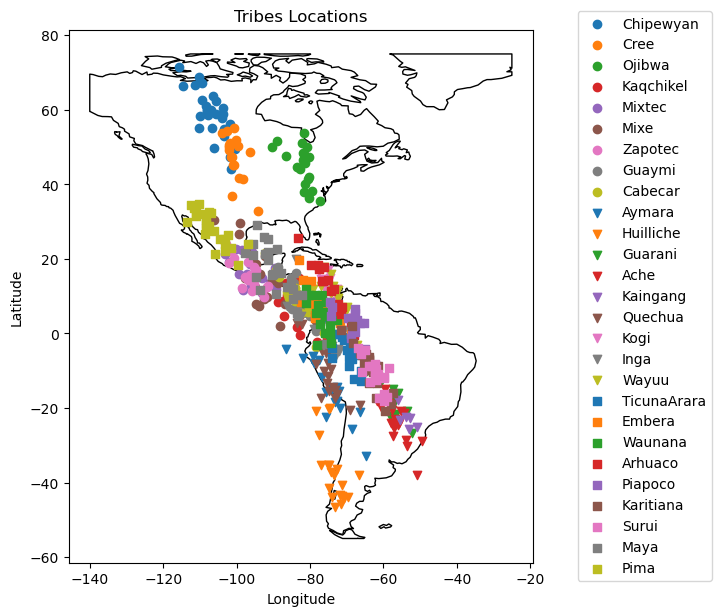

In [18]:
from sklearn.pipeline import make_pipeline

y = df[['long', 'lat']].values

scaler = StandardScaler()
pca = PCA(n_components=192)
regression = LinearRegression()
gkf = GroupKFold(n_splits=10, shuffle=True)

pipeline = make_pipeline(scaler, pca, regression)
pipeline.fit(X, y)
predictions = pipeline.predict(X)


# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = predictions[gdf['Pop'] == tribe]
    ax.scatter(members_tribe[:, 0], members_tribe[:, 1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

The model still predicts the correct general area for the tribes, but there is more variance between the points within each tribe compared to the plot from 4a. Since we are plotting the points in the training set and the testing error was much higher than the training error, we can expect the error on real data to be much higher than what the plot suggests, closer to the testing error.

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.